# Моделювання ризиків затоплення прибережної зони (Одеса)
**Курсова робота** | Студент: *Павло Патрило* | Група: *ПМі-33*

### Мета роботи
Розробка програмного інструменту для оцінки впливу підняття рівня моря на інфраструктуру міста Одеса. Робота базується на **DEM-моделюванні** (Digital Elevation Model) та використовує алгоритм пошуку в ширину (**BFS**) для точного визначення гідравлічної зв'язності затоплених зон.

### Методологія та інструменти
* **Дані:** Точна карта висот (SRTM/Copernicus DEM) з сайту: https://portal.opentopography.org/raster?opentopoID=OTSDEM.032021.4326.3.
* **Алгоритм:** Пошук вшир (BFS) для виключення "псевдо-затоплень" в ізольованих низинах.
* **Сценарії:** Використано офіційні прогнози **IPCC AR6** (2021) для різних кліматичних моделей посилання: https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_Chapter09.pdf (Table 9.9).
* **Технології:** `Python`, `Rasterio`, `GeoPandas`, `Matplotlib`, `IPyWidgets`.

---

### 1. Ініціалізація середовища
Підключення необхідних бібліотек для обробки геоданих (`Rasterio`, `GeoPandas`), математичних розрахунків (`NumPy`) та візуалізації (`Matplotlib`). Імпорт локальних модулів проекту з папки `src`.

In [11]:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

from IPython.display import display, Markdown
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from IPython.display import display, clear_output
import geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape

project_root = pathlib.Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.loader import load_dem
from src.model import FloodModel
from src.gis_utils import flood_area_km2

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

### 2. Завантаження та препроцесинг даних
Зчитування цифрової моделі рельєфу (GeoTIFF). На цьому етапі відбувається:
1. Валідація геоданих та системи координат.
2. Автоматичне калібрування "нульового" рівня моря (`sea_bias`) для корекції висот відносно локального геоїда.

In [12]:
# Шлях до файлу (основний файл)
path_to_dem = pathlib.Path('../data/raw/OSNOVA.tif')

if not path_to_dem.exists():
    path_to_dem = pathlib.Path('../data/raw/Suvorov.tif')

print(f"Завантаження DEM з: {path_to_dem.name}...")

try:
    dem, profile, bounds = load_dem(str(path_to_dem))
    model = FloodModel(dem)
    
    # Автоматичне калібрування "нуля" моря
    sea_bias = model.calibrate_sea_level()
    print(f"Розмір сітки: {dem.shape}")
    print(f"Базовий рівень моря (sea bias): {sea_bias:.3f} м")
    
except Exception as e:
    print(f"Помилка завантаження: {e}")

Завантаження DEM з: OSNOVA.tif...
Розмір сітки: (200, 435)
Базовий рівень моря (sea bias): 0.000 м


#### 2.1 Підготовка даних 
Прогнозоване підняття рівня моря по роках
- **IPCC AR6** (2021) посилання: https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_Chapter09.pdf (Table 9.9).


In [13]:
# Сценарії підвищення рівня моря (у метрах)
years = [2020, 2030, 2050, 2100, 2150]
ssp_19 = [0.0, 0.09, 0.18, 0.38, 0.57]
ssp_45 = [0.0, 0.09, 0.20, 0.56, 0.92]
ssp_85 = [0.0, 0.10, 0.23, 0.77, 1.32]

### 3. Морфометричний аналіз території
Генерація "аналітичного паспорта" місцевості. Таблиця дозволяє оцінити загальні характеристики рельєфу, розподіл висот та баланс між суходолом і водною поверхнею до початку моделювання.

In [14]:

def show_dem_statistics(dem, profile, bounds):
    """
    Генерує аналітичний звіт по DEM.
    Виправлено помилку з неоголошеними змінними для балансу територій.
    """
    # === 1. БАЗОВІ РОЗРАХУНКИ (Геометрія) ===
    rows, cols = dem.shape
    valid_mask = ~np.isnan(dem)
    valid_pixels = np.count_nonzero(valid_mask) 
    
    # Розміри пікселя
    transform = profile["transform"]
    lat = (bounds.top + bounds.bottom) / 2
    deg_to_m = 111_320
    px_w_m = transform.a * deg_to_m * np.cos(np.deg2rad(lat))
    px_h_m = -transform.e * deg_to_m
    pixel_area_km2 = (abs(px_w_m * px_h_m)) / 1e6 
    
    total_area_km2 = valid_pixels * pixel_area_km2

    # === 2. СТАТИСТИКА ВИСОТ ===
    z_min = np.nanmin(dem)
    z_max = np.nanmax(dem)
    z_mean = np.nanmean(dem)
    z_std = np.nanstd(dem)
    
    # Квантилі
    p05 = np.nanpercentile(dem, 5)
    p10 = np.nanpercentile(dem, 10)
    p25 = np.nanpercentile(dem, 25)

    # Спочатку рахуємо Bias
    w = 10
    window = dem[rows - w:rows, cols - w:cols]
    sea_bias = float(np.nanmedian(window))
    
    # Створюємо маски
    sea_mask = (dem <= sea_bias) & valid_mask
    land_mask = (dem > sea_bias) & valid_mask
    
    # Рахуємо пікселі
    sea_pixels_count = np.count_nonzero(sea_mask)
    land_pixels_count = np.count_nonzero(land_mask)
    
    # Рахуємо площу
    sea_area = sea_pixels_count * pixel_area_km2
    land_area = land_pixels_count * pixel_area_km2
    # -----------------------------------------------------

    # === 4. ФОРМУВАННЯ MARKDOWN ЗВІТУ ===
    markdown_report = f"""
### Аналітичний паспорт DEM-моделі

**1. Геометрія та Охоплення**
| Параметр | Значення | Опис |
|:---|:---|:---|
| **Розмір матриці** | `{rows} x {cols}` | Всього пікселів: `{dem.size:,}` |
| **Корисна площа** | `{total_area_km2:.2f} км²` | Площа валідних даних |
| **Розмір пікселя** | `~{px_w_m:.1f} м x {px_h_m:.1f} м` | Просторова роздільна здатність |
| **Система координат** | `{profile['crs']}` | EPSG код проєкції |

**2. Баланс Суша/Море**
| Тип поверхні | Площа (км²) | Частка (%) |
|:---|:---|:---|
| **Акваторія** | `{sea_area:.2f} км²` | `{sea_pixels_count/valid_pixels*100:.1f}%` |
| **Суходіл + внутрішні води** | `{land_area:.2f} км²` | `{land_pixels_count/valid_pixels*100:.1f}%` |
| **Рівень моря** | `{sea_bias:.3f} м` | Базова висота (калібрування) |

**3. Статистика Рельєфу (Hypsometry)**
| Метрика | Значення | Коментар |
|:---|:---|:---|
| **Діапазон висот** | `{z_min:.1f} м ... {z_max:.1f} м` | Перепад висот |
| **Середня висота** | `{z_mean:.1f} м` | (σ = `{z_std:.1f} м`) |
| **5-й персентиль** | `{p05:.1f} м` | 5% території нижче цієї висоти |
| **10-й персентиль** | `{p10:.1f} м` | 10% території нижче цієї висоти |
| **25-й персентиль** | `{p25:.1f} м` | Чверть території нижче цієї висоти |
    """
    
    display(Markdown(markdown_report))

if 'dem' in globals():
    show_dem_statistics(dem, profile, bounds)
else:
    print("Завантажте дані перед запуском статистики!")


### Аналітичний паспорт DEM-моделі

**1. Геометрія та Охоплення**
| Параметр | Значення | Опис |
|:---|:---|:---|
| **Розмір матриці** | `200 x 435` | Всього пікселів: `87,000` |
| **Корисна площа** | `57.22 км²` | Площа валідних даних |
| **Розмір пікселя** | `~21.3 м x 30.9 м` | Просторова роздільна здатність |
| **Система координат** | `EPSG:4326` | EPSG код проєкції |

**2. Баланс Суша/Море**
| Тип поверхні | Площа (км²) | Частка (%) |
|:---|:---|:---|
| **Акваторія** | `30.78 км²` | `53.8%` |
| **Суходіл + внутрішні води** | `26.45 км²` | `46.2%` |
| **Рівень моря** | `0.000 м` | Базова висота (калібрування) |

**3. Статистика Рельєфу (Hypsometry)**
| Метрика | Значення | Коментар |
|:---|:---|:---|
| **Діапазон висот** | `-6.5 м ... 66.0 м` | Перепад висот |
| **Середня висота** | `5.2 м` | (σ = `11.9 м`) |
| **5-й персентиль** | `-0.8 м` | 5% території нижче цієї висоти |
| **10-й персентиль** | `-0.2 м` | 10% території нижче цієї висоти |
| **25-й персентиль** | `0.0 м` | Чверть території нижче цієї висоти |
    

### 4. Аналіз вразливості (Flood Risk Curve)
Побудова кривої залежності втрати площі суходолу від рівня підняття води. Цей графік дозволяє виявити **критичні точки** — рівні, при яких відбувається різке збільшення площі затоплення.

 Розрахунок сценаріїв від 0 до 5.0 м...


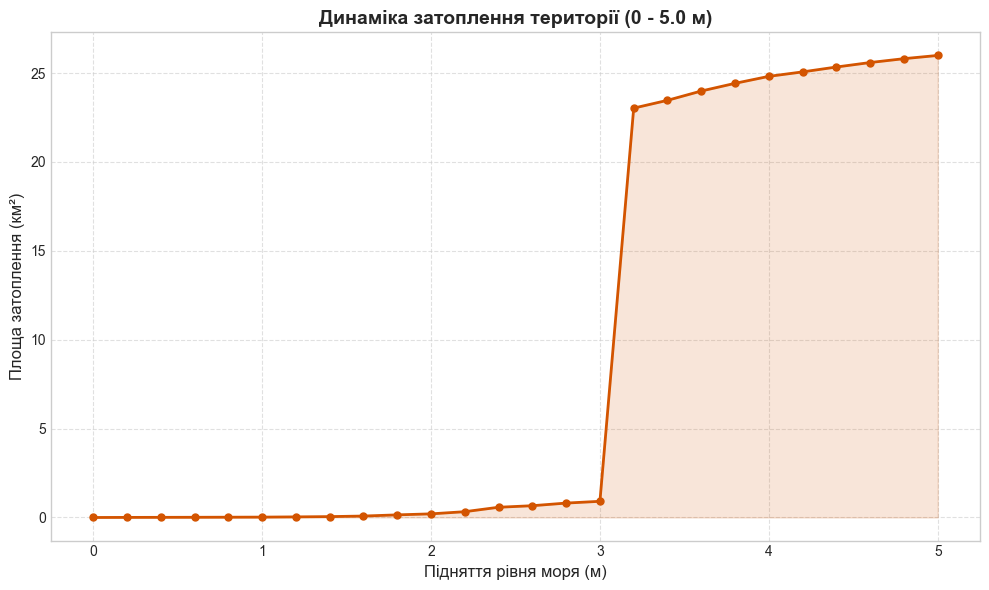

In [15]:
def plot_flood_curve(max_rise=5.0, step=0.2):
    """
    Будує графік залежності площі затоплення від рівня підняття моря (без анотацій).
    """
    print(f" Розрахунок сценаріїв від 0 до {max_rise} м...")
    
    # 1. Генеруємо сценарії
    rise_levels = np.arange(0.0, max_rise + step, step)
    areas = []
    
    # Базове море (щоб рахувати тільки втрату суші)
    base_sea = model.calculate_flood(sea_bias)
    
    # 2. Цикл розрахунку
    for h in rise_levels:
        level = sea_bias + h
        
        # Моделюємо затоплення (BFS)
        bfs_mask = model.calculate_flood(level)
        
        # Виділяємо тільки нову затоплену сушу
        risk_zone = bfs_mask & (~base_sea)
        
        # Рахуємо площу
        area = flood_area_km2(risk_zone, profile, bounds)
        areas.append(area)
        
    # 3. Побудова графіка
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    # Основна лінія
    ax.plot(rise_levels, areas, color='#d35400', marker='o', 
            linestyle='-', linewidth=2, markersize=5, label='Втрата суші')
    
    ax.fill_between(rise_levels, areas, color='#d35400', alpha=0.15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlabel('Підняття рівня моря (м)', fontsize=12)
    ax.set_ylabel('Площа затоплення (км²)', fontsize=12)
    ax.set_title(f'Динаміка затоплення території (0 - {max_rise} м)', fontsize=14, fontweight='bold')
    

    plt.tight_layout()
    plt.show()

if 'model' in globals():
    plot_flood_curve(max_rise=5.0)
else:
    print(" Спочатку ініціалізуйте модель!")

### 5. Кліматичні сценарії (IPCC AR6)
Візуалізація прогнозів на основі **Table 9.9 (Chapter 9)** та **Summary for Policymakers (SPM B.5.3)** (посилання: https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_SPM.pdf) звіту IPCC AR6.
* **SSP1-1.9:** Сценарій "Зелений курс" (1.5°C).
* **SSP1-4.5:** Стандартний Сценарій "Зелений курс" 
* **SSP5-8.5:** Стандартний песимістичний сценарій (високі викиди).
* **SSP5-8.5 Low Confidence** Верхня межа песимістичний сценарій (високі викиди, стрімке танення льодовиків) позначається *Low confidence* в Table 9.9.
* **High-Impact Storyline:** Катастрофічний сценарій (низька ймовірність, високий вплив), що враховує нестабільність льодовикових щитів Антарктиди (MICI/MISI).

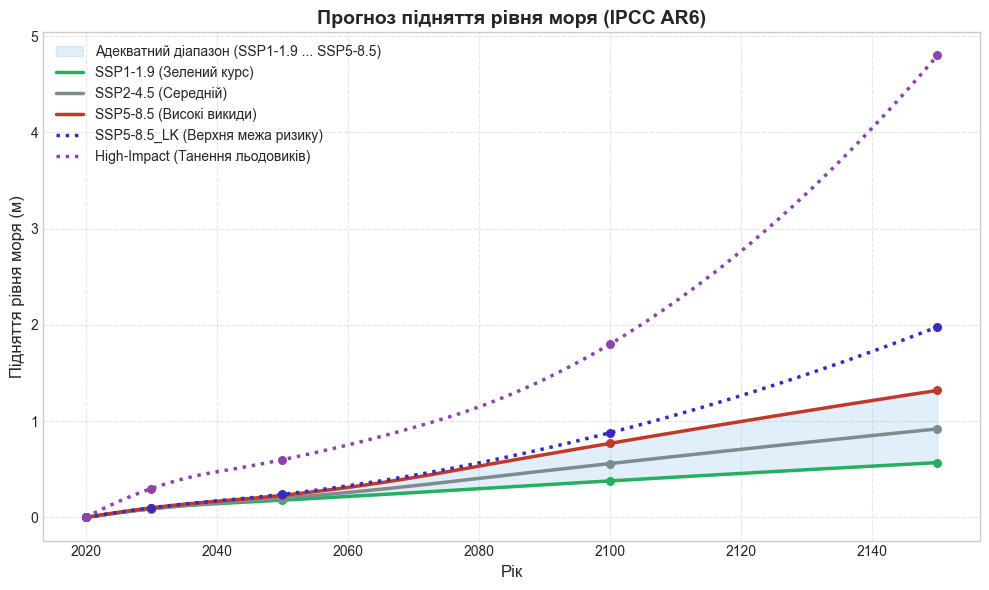

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# === ДАНІ IPCC AR6 (медіанні значення, м) ===
ipcc_data = {
    'years': years,
    'SSP1-1.9': ssp_19,   # Зелений курс (Low)
    'SSP2-4.5': ssp_45,   # Середній (Mid)
    'SSP5-8.5': ssp_85,   # Високі викиди (High)
    'SSP5-8.5_LK': [0.0, 0.10, 0.24, 0.88, 1.98], # AR6 SPM: "likely to exceed" # Верхня межа
    'High-Impact': [0.0, 0.3, 0.6, 1.80, 4.80] # AR6 SPM: "cannot be ruled out" (Ice Sheet Instability) # Катастрофічний
}

def plot_ipcc_scenarios():
    """
    Графік з синім коридором невизначеності (між SSP1-1.9 та SSP5-8.5).
    """
    # Підготовка для плавних ліній
    x_points = ipcc_data['years']
    x_smooth = np.linspace(min(x_points), max(x_points), 200)
    
    # Інтерполяція меж коридору
    f_low = interp1d(x_points, ipcc_data['SSP1-1.9'], kind='quadratic')
    f_high = interp1d(x_points, ipcc_data['SSP5-8.5'], kind='quadratic')
    
    y_low_smooth = f_low(x_smooth)
    y_high_smooth = f_high(x_smooth)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

    # === 1. МАЛЮЄМО СИНІЙ КОРИДОР ===
    ax.fill_between(x_smooth, y_low_smooth, y_high_smooth, 
                    color='#3498db', alpha=0.15, label='Адекватний діапазон (SSP1-1.9 ... SSP5-8.5)')
    
    # Налаштування ліній
    styles = {
        'SSP1-1.9': {'color': '#27ae60', 'label': 'SSP1-1.9 (Зелений курс)', 'style': '-'},
        'SSP2-4.5': {'color': '#7f8c8d', 'label': 'SSP2-4.5 (Середній)', 'style': '-'}, # Сірий, бо всередині
        'SSP5-8.5': {'color': '#c0392b', 'label': 'SSP5-8.5 (Високі викиди)', 'style': '-'},
        'SSP5-8.5_LK': {'color': "#352bc0", 'label': 'SSP5-8.5_LK (Верхня межа ризику)', 'style': ':'},
        'High-Impact': {'color': '#8e44ad', 'label': 'High-Impact (Танення льодовиків)', 'style': ':'}
    }

    # === 2. МАЛЮЄМО ЛІНІЇ ===
    for scenario, values in ipcc_data.items():
        if scenario == 'years': continue
        
        f = interp1d(x_points, values, kind='quadratic')
        y_smooth = f(x_smooth)
        
        s = styles[scenario]
        ax.plot(x_smooth, y_smooth, label=s['label'], color=s['color'], 
                linestyle=s['style'], linewidth=2.5)
        
        # Точки
        ax.scatter(x_points, values, color=s['color'], s=30, zorder=5)

    # Оформлення
    ax.set_title('Прогноз підняття рівня моря (IPCC AR6)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Рік', fontsize=12)
    ax.set_ylabel('Підняття рівня моря (м)', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=10, loc='upper left')
    


    plt.tight_layout()
    plt.show()

# Запуск
plot_ipcc_scenarios()

## Попередня модель

In [17]:
def plot_flood_scenario(water_level_rise, show_naive=False):
    """
    Функція візуалізації з виправленим відображенням червоних зон помилок.
    """
    total_level = sea_bias + water_level_rise
    
    bfs_mask = model.calculate_flood(total_level)
    base_sea = model.calculate_flood(sea_bias)
    risk_zone = bfs_mask & (~base_sea)
    
    area = flood_area_km2(risk_zone, profile, bounds)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    im = ax.imshow(dem, cmap='terrain', alpha=0.8, origin='upper', interpolation='nearest', vmin=0, vmax=100)
    
    if show_naive:
        naive_mask = model.simple_threshold(total_level)
        false_positive = naive_mask & (~bfs_mask)
        
        if false_positive.sum() > 0:
            fp_visual = np.ma.masked_where(~false_positive, false_positive)
            

            ax.imshow(fp_visual, cmap='autumn_r', alpha=0.9, origin='upper', 
                      interpolation='nearest', vmin=0, vmax=1)
            
            ax.plot([], [], color='red', label='Ізольовані низини (помилка наївної моделі)', linewidth=3)

    flood_visual = np.ma.masked_where(~bfs_mask, bfs_mask)
    ax.imshow(flood_visual, cmap='Blues', alpha=0.7, origin='upper', 
              interpolation='nearest', vmin=0, vmax=0.8)
    
    plt.colorbar(im, label='Висота над рівнем моря (м)', fraction=0.03, pad=0.04)
    
    title_text = f"Сценарій: +{water_level_rise:.2f} м | Площа затоплення: {area:.2f} км²"
    ax.set_title(title_text, fontsize=14, fontweight='bold')
    ax.axis('off')
    
    if show_naive:
        ax.legend(loc='lower left')
        
    plt.tight_layout()
    plt.show()

In [18]:
# === Віджети ===

style = {'description_width': 'initial'}

# Слайдер рівня води
slider_level = widgets.FloatSlider(
    value=1.0, 
    min=0.0, 
    max=5.0, 
    step=0.1, 
    description='Підняття рівня (м):',
    style=style,
    layout=widgets.Layout(width='60%')
)

# Чекбокс для порівняння моделей
check_naive = widgets.Checkbox(
    value=False,
    description='Показати помилки "наївної" моделі (ізольовані низини)',
    style=style
)

# Вивід графіку
out = widgets.interactive_output(
    plot_flood_scenario, 
    {'water_level_rise': slider_level, 'show_naive': check_naive}
)

# Компонування інтерфейсу
ui = widgets.VBox([
    widgets.HTML("<h2> Інтерактивна модель затоплення Одеси</h2>"),
    widgets.HBox([slider_level]),
    widgets.HBox([check_naive]),
    out
])

display(ui)

### 6. Інтерактивний симулятор (Остаточна модель)
Комплексний інструмент для сценарного моделювання.

**Функціональні можливості:**
* **Синхронізація з часом:** Слайдер автоматично підсвічує діапазон IPCC (SSP1-1.9 ... SSP5-8.5) для обраного року.
* **Експорт даних:** Генерація векторних карт ризиків з вистотами підтоплення (`GeoJSON`).
* **Детальна статистика:** Миттєвий розрахунок площі та кількості затоплених пікселів.

Після завантаження даних у векторному форматі, вставити дані на сайт: https://geojson.io/#map=10.56/46.5048/30.734

In [ ]:
# === 1. ПІДГОТОВКА ДАНИХ IPCC ===
ssp_19 = [0.0, 0.09, 0.18, 0.38, 0.57]
ssp_45 = [0.0, 0.09, 0.20, 0.56, 0.92]
ssp_85 = [0.0, 0.10, 0.23, 0.77, 1.32]
# === 1. ДАНІ IPCC (ОНОВЛЕНО з Таблиці 9.9) ===
ipcc_years = years # [2020, 2030, 2050, 2100, 2150]


data_min = ssp_19 # [0.0, 0.09, 0.18, 0.38, 0.57]

data_mid = ssp_45 # [0.0, 0.09, 0.20, 0.56, 0.92]

data_max = ssp_85 # [0.0, 0.10, 0.23, 0.77, 1.32]

# Інтерполяція
f_min = interp1d(ipcc_years, data_min, kind='quadratic', fill_value="extrapolate")
f_mid = interp1d(ipcc_years, data_mid, kind='quadratic', fill_value="extrapolate")
f_max = interp1d(ipcc_years, data_max, kind='quadratic', fill_value="extrapolate")
# === 2. ВІДЖЕТИ ===

# А) Контейнери
out_map = widgets.Output(layout=widgets.Layout(width='65%')) 
out_stats = widgets.HTML(layout=widgets.Layout(width='100%')) 

# Б) Кнопка експорту
btn_export = widgets.Button(
    description='Експорт у GeoJSON',
    button_style='info',
    icon='download',
    layout=widgets.Layout(width='100%', margin='10px 0 0 0')
)
out_export_log = widgets.Output()

# В) Елементи керування
style = {'description_width': 'initial'}
layout_full = widgets.Layout(width='98%')
SLIDER_MAX = 5.0

dropdown_year = widgets.Dropdown(
    options=[('Власний вибір (Ручний режим)', -1), ('2030', 2030), ('2050', 2050), ('2100', 2100), ('2150', 2150)],
    value=2050,
    description=' Прогноз на рік:',
    style=style, layout=layout_full
)

slider_rise = widgets.FloatSlider(
    value=0.20, min=0.0, max=SLIDER_MAX, step=0.01,
    description='🌊 Рівень (м):',
    style=style, layout=layout_full
)
slider_rise.add_class('ipcc-slider')
html_style = widgets.HTML() 
checkbox_naive = widgets.Checkbox(value=False, description='🔍 Показати помилки наївної моделі', style=style)

# === 3. ЛОГІКА ЕКСПОРТУ ===
def export_geojson(b):
    with out_export_log:
        clear_output()
        print(" Генерація векторних даних...")
        try:
            H_EXPORT = slider_rise.value
            level = sea_bias + H_EXPORT
            flood_mask = model.calculate_flood(level)
            base_mask = model.calculate_flood(sea_bias)
            new_flood = flood_mask & (~base_mask)

            if new_flood.sum() == 0:
                print(" Немає нових затоплених зон!")
                return

            depth_new = np.full_like(dem, np.nan, dtype=float)
            depth_new[new_flood] = level - dem[new_flood]

            features = []
            transform = profile["transform"]
            for geom, value in shapes(depth_new, mask=new_flood, transform=transform):
                features.append({"geometry": shape(geom), "depth_m": round(float(value), 2)})

            gdf = gpd.GeoDataFrame(features, crs=profile["crs"])
            OUT_FILE = f"flood_RISK_{H_EXPORT:.2f}m.geojson"
            gdf.to_file(OUT_FILE, driver="GeoJSON")

            print(f" Файл збережено: {OUT_FILE}")
            print(f"🔹 Об'єктів: {len(gdf)}")
            print(f"🔹 Площа: {flood_area_km2(new_flood, profile, bounds):.2f} км²")
        except Exception as e:
            print(f" Помилка: {e}")

btn_export.on_click(export_geojson)

# === 4. ОСНОВНА ЛОГІКА ОНОВЛЕННЯ ===
def update_dashboard(change=None):
    year = dropdown_year.value
    water_level_rise = slider_rise.value
    show_naive = checkbox_naive.value

    # Слайдер логіка
    if change and change['owner'] == dropdown_year:
        if year != -1:
            val_min, val_mid, val_max = float(f_min(year)), float(f_mid(year)), float(f_max(year))
            slider_rise.value = round(val_mid, 2)
            slider_rise.description = f'🌊 {year} (діапазон {val_min:.2f}...{val_max:.2f} м):'
            
            pct_start = min(max((val_min / SLIDER_MAX) * 100, 0), 100)
            pct_end = min(max((val_max / SLIDER_MAX) * 100, 0), 100)
            
            html_style.value = f"""<style>.ipcc-slider .widget-slider .slider-track {{
                background: linear-gradient(to right, #e0e0e0 0%, #e0e0e0 {pct_start}%, #3498db {pct_start}%, #3498db {pct_end}%, #e0e0e0 {pct_end}%, #e0e0e0 100%) !important;
            }}</style>"""
        else:
            slider_rise.description = '🌊 Ручний режим (м):'
            html_style.value = "<style>.ipcc-slider .widget-slider .slider-track { background: #e0e0e0 !important; }</style>"

    # Розрахунки
    total_level = sea_bias + water_level_rise
    bfs_mask = model.calculate_flood(total_level)
    base_sea = model.calculate_flood(sea_bias)
    risk_zone = bfs_mask & (~base_sea)
    flooded_area = flood_area_km2(risk_zone, profile, bounds)
    
    # === НОВЕ: Площа в м2 ===
    flooded_area_m2 = flooded_area * 1_000_000
    
    # Метрики
    rows, cols = dem.shape
    total_pixels = dem.size
    flooded_pixels_count = np.count_nonzero(risk_zone)

    # === HTML ДЛЯ ТАБЛИЦІ ===
    stats_html = f"""
    <div style="font-family: 'Segoe UI', sans-serif; color: #333;">
        <h3 style="border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 0;">📊 Технічні метрики</h3>
        <table style="width: 100%; border-collapse: collapse;">
            
            <tr style="border-bottom: 1px solid #eee;">
                <td style="padding: 8px 0; white-space: nowrap;"><strong>Рівень підняття:</strong></td>
                <td style="text-align: left; padding-left: 20px; color: #2980b9; font-weight: bold;">+{water_level_rise:.2f} м</td>
            </tr>
            
            <tr style="border-bottom: 1px solid #eee;">
                <td style="padding: 8px 0; white-space: nowrap;"><strong>Затоплена площа:</strong></td>
                <td style="text-align: left; padding-left: 20px;">
                    <b>{flooded_area:.2f} км²</b> 
                    <span style="color: #7f8c8d; font-size: 0.85em;">({flooded_area_m2:,.0f} м²)</span>
                </td>
            </tr>
            
            <tr style="border-bottom: 1px solid #eee;">
                <td style="padding: 8px 0; white-space: nowrap;"><strong>Розмір растру:</strong></td>
                <td style="text-align: left; padding-left: 20px; font-family: monospace;">{rows} x {cols}</td>
            </tr>
            
            <tr style="border-bottom: 1px solid #eee;">
                <td style="padding: 8px 0; white-space: nowrap;"><strong>Всього пікселів:</strong></td>
                <td style="text-align: left; padding-left: 20px; font-family: monospace;">{total_pixels:,}</td>
            </tr>
            
            <tr>
                <td style="padding: 8px 0; white-space: nowrap;"><strong>Новозатоплені пікс:</strong></td>
                <td style="text-align: left; padding-left: 20px; color: #c0392b; font-weight: bold; font-family: monospace;">{flooded_pixels_count:,}</td>
            </tr>
            
        </table>
    </div>
    """
    out_stats.value = stats_html

    # Карта
    with out_map:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
        im = ax.imshow(dem, cmap='terrain', alpha=0.9, origin='upper', interpolation='nearest', vmin=0, vmax=100)
        if show_naive:
            naive_mask = model.simple_threshold(total_level)
            fps = naive_mask & (~bfs_mask)
            if fps.sum() > 0:
                ax.imshow(np.ma.masked_where(~fps, fps), cmap='autumn_r', alpha=1.0, origin='upper', interpolation='nearest', vmin=0, vmax=1)
                ax.plot([], [], color='red', label='Помилка наївної моделі', linewidth=2)
                ax.legend(loc='lower left', fontsize=8)
        ax.imshow(np.ma.masked_where(~bfs_mask, bfs_mask), cmap='Blues', alpha=0.7, origin='upper', interpolation='nearest', vmin=0, vmax=0.8)
        ax.axis('off')
        ax.set_title(f"Карта затоплення (+{water_level_rise:.2f} м)", fontsize=11, color='#555')
        plt.tight_layout()
        plt.show()

# === 5. ЗАПУСК ===
dropdown_year.observe(update_dashboard, names='value')
slider_rise.observe(update_dashboard, names='value')
checkbox_naive.observe(update_dashboard, names='value')

controls = widgets.VBox([dropdown_year, slider_rise, html_style, checkbox_naive], layout=widgets.Layout(margin='0 0 20px 0'))

right_panel = widgets.VBox(
    [out_stats, btn_export, out_export_log], 
    layout=widgets.Layout(width='35%', padding='20px 0 0 20px')
)

main_display = widgets.HBox([out_map, right_panel], layout=widgets.Layout(align_items='flex-start'))

ui = widgets.VBox([
    widgets.HTML("<h2 style='text-align: center; color: #2c3e50;'> Інтерактивна модель затоплення</h2>"),
    controls,
    main_display
])

update_dashboard({'owner': dropdown_year, 'new': dropdown_year.value})
display(ui)

In [20]:
import folium

m = folium.Map(location=[46.4925, 30.7233], zoom_start=12)

folium.GeoJson(
    "flood_RISK_2.02m.geojson", 
    name="Зони затоплення",
    style_function=lambda x: {
        'fillColor': '#0000ff', 
        'color': '#0000ff',     
        'weight': 1,
        'fillOpacity': 0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['depth_m'], 
        aliases=['Глибина затоплення (м):']
    ) 
).add_to(m)

folium.LayerControl().add_to(m)

m


In [21]:
print(f"Розрахунок завершено успішно")

Розрахунок завершено успішно


### 7. Висновки та результати

В ході виконання курсової роботи було розроблено програмний комплекс для моделювання ризиків затоплення прибережної зони міста Одеса.

**Ключові результати:**

1.  **Розробка інструментарію:** Створено інтерактивний дашборд на базі `Python` (Rasterio, Matplotlib, IPyWidgets), який дозволяє моделювати сценарії підняття рівня моря в реальному часі.
2.  **Алгоритмічна точність:** Реалізація алгоритму **BFS (Breadth-First Search)** дозволила виключити "псевдо-затоплення" (ізольовані низини, не з'єднані з морем), що підвищило точність оцінки площі ризику.
3.  **Аналіз сценаріїв IPCC AR6:**
    * За оптимістичним сценарієм (**SSP1-1.9**), підняття рівня моря до 2100 року (~0.38 м) не несе критичної загрози для основної інфраструктури міста.
    * За песимістичним сценарієм (**SSP5-8.5**), підняття рівня до ~1.0 м створює ризики підтоплення портової інфраструктури та низинних районів (Пересип).
    * Катастрофічний сценарій (**High-Impact Storyline**, >2.0 м) демонструє можливість затоплення значних площ, що вимагатиме масштабних інженерних рішень.
4.  **Практичне значення:** Отримана модель дозволяє експортувати зони ризику у формат `GeoJSON` для подальшого використання містобудівниками та службами ДСНС.

